# Tutorial 1: Molecules in Space

_Sandra Brünken, Herma Cuppen, Marijke Haverkorn_

## Introduction

In this tutorial you will learn how to run an astrochemical gas-phase model.
The tutorial is based on a tutorial by Tom Millar and Catherine Walsh. The code
that we will use is from the UMIST Database for Astrochemistry (UDfA)
(McElroy et al, 2013; Millar et al., 2024). Like many older scientific computer
programs, this code is written in Fortran and is easiest to run in a Linux
environment. Hence, we recommend to run this tutorial through Google Colab, a
cloud-based Jupyter Notebook environment.

## Downloading the model

First, you will download the code for the gas-phase model. The code block below
will download and unpack the code.

In [ ]:
%%bash

# make sure old files are cleaned up
rm -f *.tgz *.out *.f *.o *.specs *.rates *.state *.pdf *.txt makefile model

# download model
curl -OLsS https://github.com/lkkmpn/intercat-school-2026/raw/refs/heads/main/files/chem-model.tgz

# unpack model
tar -xvf chem-model.tgz

You can see the files you just downloaded by clicking on the 'Files' icon in the
sidebar on the left:

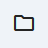

You should see the following list of files:

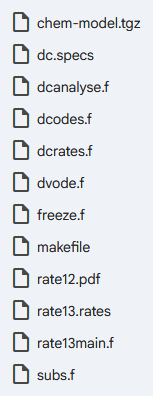

There will be some other files that exist by default in Colab, you don't need to
worry about those.

Double-clicking on a file opens it in a new pane on the right, allowing you to
view and edit it.

## Compiling the model

The files with the extension `.f` are Fortran programs, which need to be
compiled and linked together into a single executable. The rules to compile them
are defined in the file called `makefile`.

To compile the model, run the `make` command. This reads the file `makefile`,
executing the rules required to compile the model.

You can run a command in Colab in two ways:

* Open a terminal window using the 'Terminal' button in the bottom left, and
  type your commands in the terminal window;
* Run the command in a Jupyter code block by prefixing it with `!`, as shown
  below.

Both methods work the same, you can do whichever you prefer.

Compiling will take a few seconds; you will see a number of warnings, but you
don't have to worry about these.

In [ ]:
!make

After compilation, a new file called `model` is created. This is an executable
file, which will run the model when you run it.

## Inspecting the input files

Open the species file `dc.specs`. The file contains the following columns:

1. The species number;
2. The species name by its chemical formula, e.g., carbon monoxide is `CO` and
   formaldehyde is `H2CO`;
3. The initial fractional abundances, relative to the total number of
   $\mathrm{H}$ nuclei;
4. The species mass in atomic units.

Scroll to the end of the file to see how many species are included in this
chemical network. In research typically even larger networks are used. Note that
$\mathrm{H}_2$ and $\mathrm{e}^-$ have not been assigned a species number. This
is because they are treated as conserved species in the network and thus do not
require an ordinary differential equation (ODE). The electron density is, for
instance, calculated by adding all abundances of cationic species and
subtracting all abundances of anionic species, leading to an overall charge
neutrality of the cloud.

Next, have a look at the rates file `rate13.rates`. This file has a number of
colon-separated columns. In its simplest format, each line contains the
following columns:

1. Reaction number
2. Reaction type
3. Reactant 1
4. Reactant 2
5. Product 1
6. Product 2
7. Product 3
8. Product 4
9. Number of $T$ fields
10. $\alpha$
11. $\beta$
12. $\gamma$
13. Minimum temperature
14. Maximum temperature
15. Source type (laboratory, theory, review, etc.)
16. Accuracy
17. Reference

Note the strict format of the file and the fact that not all fields have
entries. The following table lists the types (column 2) and number of reactions
in UDfA.

| Code | Reaction type | Count |
| --- | --- | --- |
| AD | Associative Detachment | 132 |
| CD | Collisional Dissociation | 14 |
| CE | Charge Exchange | 579 |
| CP | Cosmic-Ray Proton (CRP) | 11 |
| CR | Cosmic-Ray Photon (CRPHOT) | 249 |
| DR | Dissociative Recombination | 531 |
| IN | Ion-Neutral | 2589 |
| MN | Mutual Neutralisation | 981 |
| NN | Neutral-Neutral | 619 |
| PH | Photoprocess | 336 |
| RA | Radiative Association | 92 |
| REA | Radiative Electron Attachment | 24 |
| RR | Radiative Recombination | 16 |

Each row represents a chemical reaction with the reactants in columns 3–4 and
the products in columns 5–8. In some cases, the behaviour of the rate
coefficient has a complex dependence on temperature and more than one set of
parameters are needed to describe this behaviour. Column 9 indicates the number
of temperature fields and columns 10–17 are repeated the appropriate number of
times. The Fortran codes contain a subroutine that can read the correct set of
parameters for any given temperature.

The entries in columns 10–12, $\alpha$, $\beta$ and $\gamma$, are values for
computation of the rate constant for each reaction. How this is computed depends
on the type of reaction as explained during the lecture and in the book. For
ion-neutral reactions, this is
$$ k = \alpha \left( \frac{T}{300} \right)^\beta \exp(-\gamma / T), $$
and for cosmic-ray ionisation
$$ k = \alpha. $$

Scrolling through the file you will see that photo-processes (type PH), direct
cosmic-ray ionisation (type CP) and cosmic-ray induced photo-processes (type CR)
are identified by having `PHOTON`, `CRP`, and `CRPHOT` as the second reactant,
respectively.

Finally, columns 12 and 13 contain the minimum and maximum temperatures,
respectively, in which the rate coefficient, and the specific values of
$\alpha$, $\beta$ and $\gamma$, applies. References to the source of the data,
either papers or the unique paper identifier DOI, are given for each reaction in
column 17.

Take some time to scroll through the file and identify examples of all the
reactions in the table. Radiative processes (types RA, REA and RR) involve the
emission of a photon and dissociative recombination (type DR) is the reaction
between a cation (a positively charged ion) and an electron that leads to
fragmentation of the cation.

If we like to look up the cosmic ray ionisation of helium, we could search in
the file for `:CP:He:`. This leads to reaction 734 with the following input:

```
734:CP:He:CRP:He+:e-:::1:6.50e-18:0.00:0.0:10:41000:L:C:"BL75":"rate06_blank_refs_CP.notes":
```

The rate constant can then be obtained as
$k = 6.50 \cdot 10^{-18}\,\mathrm{s}^{-1}$ using $\alpha = 6.50 \cdot 10^{-18}$,
$\beta = 0$, and $\gamma = 0$.

<hr>

Find the following reactions and calculate their rate constants at 10 K:

$$
\begin{align}
\mathrm{H}_2 + \mathrm{CRP} &\to \mathrm{H}_2^+ + \mathrm{e}^- \\
\mathrm{H}_2^+ + \mathrm{H}_2 &\to \mathrm{H}_3^+ + \mathrm{H} \\
\mathrm{H}_3^+ + \mathrm{CO} &\to \mathrm{HCO}^+ + \mathrm{H}_2 \\
\mathrm{H}_3^+ + \mathrm{O} &\to \mathrm{OH}^+ + \mathrm{H}_2
\end{align}
$$

You will need these later.

💡 **Tip:** This is a large file, and unfortunately you cannot easily search in
files in Colab. You can view the entire file in a new browser tab
[by clicking here](https://raw.githubusercontent.com/lkkmpn/intercat-school-2026/refs/heads/main/files/chem-model/rate13.rates),
after which you can search in the file using Ctrl + F.

<hr>

The file `dcodes.f` contains the ordinary differential equations (ODEs)
describing the rate of change of species abundance with time. This file is
different in that it is essentially a Fortran program. Don't worry too much
about the preamble, instead scroll down to line 944 where the ODE for
$\mathrm{H}_3^+$ is built. All terms involved in the formation of
$\mathrm{H}_3^+$ are added to `F`. The rate coefficients are given by `K(*)` and
each species' current abundance by `Y(*)`, with `*` replaced by either the
species number or reaction number as given in the species and rates files
respectively. The term `HNR` is included in every term describing a two-body
reaction and is set to 1.0 in dark cloud/interstellar models. Despite its
redundant nature here, it is included because the same form of ODE can be used
to describe the flow in a uniformly expanding gas, such as the circumstellar
envelope around late-type stars. In this case, `Y(*)` is defined to be the
fractional abundance and `HNR` is defined as the number density at radial
distance $r$. Depending on whether a reaction is unimolecular or bimolecular,
there are one or two `Y(*)` terms.

The destruction terms are added in `D`. Since all these terms depend on the
$\mathrm{H}_3^+$ fractional abundance it is not considered here, but accounted
for later when `F` and `D` are combined to get the rate of change `YDOT` in line
1012.

Finally, have a look at the program main source code which is located in the
file `rate13main.f`. Near the beginning of the file you will see where the input
and output files are defined. Physical parameters for the cloud—density,
temperature, visual extinction, etc.—and for the grains are defined around
lines 60–80. The density $n_{\mathrm{H}}$ is called `DN` in the model.

<hr>

## Running the model

You can run the model by executing the compiled `model` executable. Again, you
can do this from the terminal window by typing `./model` and pressing Enter, or
from a Jupyter code block by prefixing it with `!`. Once you do either, the
model will begin to run an as it executes it will write data, including its
initial data, to the screen to show how it is progressing.

In [ ]:
!./model

The program writes three files in the course of its execution.

One is a more readable set of chemical reactions, called `rates.txt`. A second
file, `rate13steady.state`, contains the initial conditions as well as the
fractional abundances of all species at the last time step
($10^8\,\mathrm{yr}$), by which time the models should have reached
steady-state. The fractional abundance is with respect to the total $\mathrm{H}$
nuclei abundance and not with respect to $\mathrm{H}_2$. This file is very
useful for getting a feel as to whether the detailed output can be trusted. At
steady-state, which should be reached in all dark cloud calculations in which
freeze-out is ignored, $\frac{\mathrm{d} f(i)}{\mathrm{d} t} = 0$ and the
abundances are given by the solution of algebraic rather than ordinary
differential equations.

Open this file and look up the initial conditions for $\mathrm{H}_2$, elemental
$\mathrm{C}$ (this is initially all $\mathrm{C}^+$), and elemental $\mathrm{O}$,
and the steady-state abundances of $\mathrm{CO}$, $\mathrm{O}$,
$\mathrm{H}_3^+$, and $\mathrm{H}_2^+$.

<hr>

Return to the chemical reactions in equations (1)–(4). Assume a steady state in
both $\mathrm{H}_2^+$ and $\mathrm{H}_3^+$ and find an expression for their
steady-state concentrations. This expression will depend on the rate constants
of the four reactions as well as (for $\mathrm{H}_3^+$) the concentrations of
$\mathrm{CO}$ and $\mathrm{O}$.

Assume that all elemental $\mathrm{C}$ is converted to $\mathrm{CO}$ and the
remaining $\mathrm{O}$ is equally distributed among $\mathrm{O}$ and
$\mathrm{O}_2$. Calculate the fractional abundances for $\mathrm{CO}$ and
$\mathrm{O}$. How does this assumption compare to the values found above?

Calculate the steady-state concentrations for $\mathrm{H}_2^+$ and
$\mathrm{H}_3^+$ relative to the total density of $\mathrm{H}$ using these
assumptions. How do these concentrations compare to those found above?

<hr>

The third file, `dc.out`, contains the full output of the model. You will be
rerunning the model a few times, and every time you do so, the file `dc.out`
will be overwritten. Therefore, we recommend you rename this file every time
after having run the model. You can do this in the Files tab by hovering over
the `dc.out` file, clicking the three dots on the right, and choosing "Rename
file". Alternatively, you can use the `mv` ('move') command:

In [ ]:
!mv dc.out dc_base_output.out

We have provided you with a helper function to visualize the output of the
model. You can get Jupyter to print more information about this function with
`??`, as shown below.

In [ ]:
from ics26.molecules_in_space import plot_abundances

plot_abundances?

Use the numbers from the previous part as reference abundances, and plot the
abundances as function of time.

In [ ]:
# FILL IN YOUR NUMBERS BELOW
reference_abundances = {
    'H3+': ...,
    'CO': ...,
    'O': ...,
}

plot_abundances(
    filename='dc_base_output.out',
    plot_species=['H3+', 'CO', 'O', 'C+'],
    reference_abundances=reference_abundances,
)

How long does it take to reach steady state?

<hr>

A dense molecular cloud has a lifetime of around $10^6\,\mathrm{yr}$. Would the
steady-state approximation work in this case?

<hr>

You will now rerun the model with changed density.

Increase the density `DN` (line 67 in `rate13main.f`) by an order of magnitude
and save the file.

💡 **Tip:** You can open `rate13main.f` by double-clicking on the file in the
Files tab. You can then scroll down to line 67, change the density, and save by
pressing Ctrl + S.

Because you have edited one of the Fortran programs, you must run the `make`
command again to recompile the code. Run `./model` afterwards. (Don't forget to
rename `dc.out` from the previous run if you haven't done so!) What do you see
at higher density in terms of time and abundance of $\mathrm{H}_3^+$? Can you
explain?

In [ ]:
# edit file, run `make`, then `./model`, then rename the output file

In [ ]:
plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME
    plot_species=['H3+', 'CO', 'O', 'C+'],
    reference_abundances=reference_abundances,
)

<hr>

Go back to the original choice of density, `DN = 1e4`.

## Effect of freeze-out

Now we will look at how freezing of gas-phase species to the dust grains affects
the gas-phase chemistry.

<hr>

Switch on freeze-out of molecules onto the dust grains by setting `IFREEZE = 1`
(lines 71–74) in the main program `rate13main.f`. Save, recompile, and run the
model again. Make the same abundance plot, now including freeze-out results.
What has changed? Can you understand the effect for $\mathrm{CO}$ and
$\mathrm{H}_3^+$?

In [ ]:
# edit file, run `make`, then `./model`, then rename the output file

In [ ]:
plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME
    plot_species=['H3+', 'CO', 'O', 'C+'],
)

<hr>

To see the effects of density on freeze-out, increase the density in the main
program by an order of magnitude. What difference does this make to the
abundances as a function of time? Do you understand why?

In [ ]:
# edit file, run `make`, then `./model`, then rename the output file

In [ ]:
plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME
    plot_species=['H3+', 'CO', 'O', 'C+'],
)

Go back to the original choice of density, `DN = 1e4`, set `IFREEZE = 0`, and
recompile.

In [ ]:
# edit file, run `make`

<hr>

## Carbon- versus oxygen-rich stars

Our 'standard model' uses oxygen-rich initial element abundances. The initial
abundances adopted are listed in the file `dc.specs` in column 3, while the
molecular mass in atomic mass units is given in column 4. Open this file and
scroll through the list of species to see which species are initialised—you can
see that several elements are listed in their ionic form. We can vary these
abundances to account for changes in the elemental composition of different
astrophysical environments. Most environments can be classified as oxygen-rich
($\mathrm{O}/\mathrm{C} > 1$) or carbon-rich ($\mathrm{O}/\mathrm{C} < 1$).

To vary the initial abundances, we edit the species file. As the abundances are
read in from this file when the model is run, the code does not need to be
recompiled. Run the model with an elemental oxygen fractional abundance of
$10^{-4}$, and plot the results again.

In [ ]:
# edit file, run `./model`, then rename the output file

In [ ]:
plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME
    plot_species=['H3+', 'CO', 'O', 'C+'],
    reference_abundances=reference_abundances,
)

<hr>

The observed abundance for $\mathrm{O}_2$ in TMC-1 is an upper limit of
$f(\mathrm{O}_2) < 10^{-6}$. A series of even-numbered carbon chains
$\mathrm{C}_n\mathrm{H}$ has been observed at
$f(\mathrm{C}_4\mathrm{H}) = 3.36 \cdot 10^{-8}$,
$f(\mathrm{C}_6\mathrm{H}) = 4.10 \cdot 10^{-10}$, and
$f(\mathrm{C}_8\mathrm{H}) = 2.1 \cdot 10^{-11}$.

Considering that

* $\mathrm{O}_2$ forms via $\mathrm{O} + \mathrm{OH}$ and reacts with
  $\mathrm{C}$,
* carbon chain species form through a series of reactions initiated by
  $\mathrm{C} + \mathrm{H}_3^+ \to \mathrm{CH}^+ + \mathrm{H}_2$; the main
  destruction of these and intermediate species is through reaction with
  $\mathrm{O}$,

in which case do you expect the best agreement with observations: for the
carbon-rich model or for the standard oxygen-rich model?

<hr>

Plot the $\mathrm{O}_2$ and $\mathrm{C}_n\mathrm{H}$ abundances for both models
with the observational values. Based on these molecules, which shows a better
agreement?

💡 **Tip:** You have already run both models; if you diligently renamed the
output files, you can reuse them for these plots.

In [ ]:
reference_abundances_tmc1 = {
    'O2': 1e-6,
    'C4H': 3.36e-8,
    'C6H': 4.10e-10,
    'C8H': 2.1e-11,
}

plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME FOR THE OXYGEN-RICH MODEL
    plot_species=['O2', 'C4H', 'C6H', 'C8H'],
    reference_abundances=reference_abundances_tmc1,
)

plot_abundances(
    filename=...,  # YOUR OUTPUT FILE NAME FOR THE CARBON-RICH MODEL
    plot_species=['O2', 'C4H', 'C6H', 'C8H'],
    reference_abundances=reference_abundances_tmc1,
)